In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf
import cvxpy as cp

# **List of Tickers, Start Dates, and Frequencies**

We are taking 15 year monthly data on the largest ETFs and Mutual Funds in each financial sector. They are as follows


| Financial Sector | ETF | Mutual Fund|
|------------------|-----|------------|
| NASDAQ | `^IXIC` | `^IXIC` |
| Technology | `VGT` | `VITAX`|
| Financial Services | `XLF` |`VFAIX` |
| Consumer Cyclical | `XLY` |`BPTRX` |
| Consumer Defensive | `XLP` | `VCSAX`|
| Communication Services | `VOX` |`VTCAX` |
| Industrials | `XLI` |`VINAX` |
| Basic Materials | `XLB` |`VMIAX` |
| Energy |`XLE` |`VENAX` |
| Healthcare | `XLV` |`VGHCX` |
| Utilities | `XLU` | `VUIAX`|
| Real Estate | `VNQ` |`VGSLX` |

In [25]:
etf_tickers_NASDAQ = ['^IXIC','VGT', 'XLF', 'XLY', 'XLV', 'VOX', 'XLI', 'XLP', 'XLE', 'VNQ', 'XLB', 'XLU']
etf_tickers = ['VGT', 'XLF', 'XLY', 'XLV', 'VOX', 'XLI', 'XLP', 'XLE', 'VNQ', 'XLB', 'XLU']
mf_tickers_NASDAQ = ['^IXIC', 'VITAX', 'VFAIX', 'BPTRX', 'VGHCX', 'VTCAX', 'VINAX', 'VCSAX', 'VENAX', 'VGSLX', 'VMIAX', 'VUIAX']
mf_tickers = ['VITAX', 'VFAIX', 'BPTRX', 'VGHCX', 'VTCAX', 'VINAX', 'VCSAX', 'VENAX', 'VGSLX', 'VMIAX', 'VUIAX']

start_date_15yr = '2009-12-01'
end_date = '2025-01-04'

day = '1d'
week = '1wk'
month = '1mo' 

# **Data Ingestion**

In [26]:
def import_stock_data(tickers, start_date, end_date, frequency):
    data = yf.download(tickers, start=start_date, end=end_date, interval=frequency, auto_adjust=True)
    data = data['Close']
    data = data.dropna()
    data = data.reindex(columns=tickers)
    data.index = pd.to_datetime(data.index)
    return data

def log_returns(data):
    return np.log(1 + data.pct_change()).dropna()

def returns_cov_matrix(data):
    return data.cov()

In [27]:
log_returns_dict = {}

etf_data_nasdaq = import_stock_data(etf_tickers_NASDAQ, start_date_15yr, end_date, month)
etf_log_returns_nasdaq = log_returns(etf_data_nasdaq)
log_returns_dict['ETF with NASDAQ, 15 Year Monthly'] = etf_log_returns_nasdaq

etf_data = import_stock_data(etf_tickers, start_date_15yr, end_date, month)
etf_log_returns = log_returns(etf_data)
log_returns_dict['ETF, 15 Year Monthly'] = etf_log_returns

mf_data_nasdaq = import_stock_data(mf_tickers_NASDAQ, start_date_15yr, end_date, month)
mf_returns_nasdaq = log_returns(mf_data_nasdaq)
log_returns_dict['Mutual Fund with NASDAQ, 15 Year Monthly'] = mf_returns_nasdaq

mf_data = import_stock_data(mf_tickers, start_date_15yr, end_date, month)
mf_returns = log_returns(mf_data)
log_returns_dict['Mutual Fund, 15 Year Monthly'] = mf_returns

log_returns_dict['ETF with NASDAQ, 15 Year Monthly'].head()

[*********************100%***********************]  12 of 12 completed
[*********************100%***********************]  11 of 11 completed
[*********************100%***********************]  12 of 12 completed
[*********************100%***********************]  11 of 11 completed


Ticker,^IXIC,VGT,XLF,XLY,XLV,VOX,XLI,XLP,XLE,VNQ,XLB,XLU
Date,,,,,,,,,,,,
2010-01-01,-0.055171,-0.080756,-0.011690,-0.023863,0.012245,-0.053996,-0.008388,-0.000826,-0.039598,-0.043971,-0.084837,-0.037423
2010-02-01,0.041464,0.044072,0.034653,0.054194,0.003829,0.011823,0.051950,0.031188,0.029648,0.054329,0.044134,-0.013295
2010-03-01,0.068920,0.064895,0.082973,0.073265,0.022982,0.063531,0.079936,0.032755,0.024284,0.089528,0.074017,0.017688
2010-04-01,0.026027,0.021832,0.015357,0.060451,-0.036340,0.007974,0.045113,-0.006572,0.044206,0.076539,0.004229,0.034821
2010-05-01,-0.086591,-0.083313,-0.096053,-0.072960,-0.067306,-0.045495,-0.095617,-0.047434,-0.121609,-0.054822,-0.100176,-0.056772


# **Summary Tables**

Next, we calculate the summary statistics for our data. The data for the summary tables must be in log-returns

In [28]:
def summary_table(data, frequency):
  total_return = np.exp(data.sum()) - 1
  num_years = (data.index[-1] - data.index[0]) / pd.Timedelta(days=365.25)
  annual_return = (total_return+1)**(1/num_years)-1
  variance = data.var()
  volatility = variance**(1/2)

  if frequency == day:
    scale=252
  elif frequency ==week:
    scale=52.18
  elif frequency ==month:
    scale=12
  elif frequency == year:
    scale=1
  annualized_variance = variance*scale
  annualized_volatility = annualized_variance**(1/2)

  summary = pd.DataFrame({
      'Total Return': (total_return.values)*100,
      'Yearly Return': (annual_return.values)*100,
      'Volatility': volatility*100,
      'Annualized Volatility': annualized_volatility*100
  })
  return(summary)

In [29]:
etf_nasdaq_summary = summary_table(log_returns_dict['ETF with NASDAQ, 15 Year Monthly'], month)
etf_nasdaq_summary.head()

,Total Return,Yearly Return,Volatility,Annualized Volatility
Ticker,,,,
^IXIC,764.968834,15.468586,4.935771,17.098013
VGT,1197.644046,18.633402,5.299266,18.357196
XLF,478.281697,12.410526,5.614120,19.447881
XLY,845.504175,16.155897,5.338577,18.493373
XLV,513.080519,12.849275,3.913210,13.555758


# **Optimization**

Helper optimization functions that will be used in the next section

In [30]:
def nonnegative_optimization(data, frequency, mu):
    summary = summary_table(data, frequency)
    r = summary['Yearly Return'].values / 100
    Sigma = returns_cov_matrix(data).values
    n = len(r)

    x = cp.Variable(n)
    constraints = [
        r @ x == mu,
        cp.sum(x) == 1,
        x >= 0
    ]
    objective = cp.Minimize(cp.quad_form(x, Sigma))
    problem = cp.Problem(objective, constraints)
    problem.solve()

    if problem.status not in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE):
        return None

    if frequency == day:
        scale = 252
    elif frequency == week:
        scale = 52.18
    elif frequency == month:
        scale = 12
    else:
        scale = 1

    weights = x.value
    variance = weights.T @ Sigma @ weights
    annualized_variance = variance * scale
    annualized_volatility = annualized_variance ** (1 / 2)

    weights_df = pd.DataFrame(weights * 100, index=summary.index, columns=["Weight"])
    vol_df = pd.DataFrame({
        "Weight": [variance ** (1 / 2) * 100, annualized_volatility * 100]
    }, index=["Volatility", "Annualized Volatility"])

    return pd.concat([weights_df, vol_df])


def multi_optimization(data, frequency, mu_list):
    results = []
    for mu in mu_list:
        portfolio = nonnegative_optimization(data, frequency, mu)
        if portfolio is None:
            print(f"Skipping target return {mu*100:.1f}% â€” outside feasible range.")
            continue
        portfolio = portfolio.rename(columns={"Weight": mu * 100})
        results.append(portfolio)
    combined = pd.concat(results, axis=1)
    combined.index.name = "Ticker"
    combined.reset_index(inplace=True)
    return combined

# **Efficient Frontier**

In [31]:
def efficient_frontier_cml(log_returns, frequency, risk_free_rate):
    summary = summary_table(log_returns, frequency)
    returns = summary['Yearly Return'] / 100

    mu_min = returns.min()
    mu_max = returns.max()
    mu_values = np.linspace(mu_min, mu_max, 200)

    volatilities = []
    yearly_returns = []

    for mu in mu_values:
        portfolio = nonnegative_optimization(log_returns, frequency, mu)
        if portfolio is None:
            continue
        annualized_volatility = portfolio.loc["Annualized Volatility", "Weight"]
        volatilities.append(annualized_volatility)
        yearly_returns.append(mu * 100)

    volatilities = np.array(volatilities).astype(float)
    yearly_returns = np.array(yearly_returns).astype(float)

    sharpe_ratios = (yearly_returns / 100 - risk_free_rate) / (volatilities / 100)
    max_sharpe_idx = sharpe_ratios.argmax()
    min_vol_idx = volatilities.argmin()

    max_sharpe_vol = volatilities[max_sharpe_idx]
    max_sharpe_ret = yearly_returns[max_sharpe_idx]
    min_vol = volatilities[min_vol_idx]
    min_vol_ret = yearly_returns[min_vol_idx]

    cml_x = np.linspace(0, max_sharpe_vol * 1.2, 200)
    slope = (max_sharpe_ret / 100 - risk_free_rate) / (max_sharpe_vol / 100)
    cml_y = risk_free_rate * 100 + slope * cml_x

    plt.figure(figsize=(10, 6))
    plt.plot(volatilities, yearly_returns, 'bo', markersize=3, label='Efficient Frontier')
    plt.plot(cml_x, cml_y, 'r--', label='Capital Market Line')
    plt.scatter(max_sharpe_vol, max_sharpe_ret, color='green', s=120,
                label='Max Sharpe Portfolio', marker='*')
    plt.scatter(min_vol, min_vol_ret, color='purple', s=120,
                label='Minimum Volatility Portfolio', marker='*')
    plt.title(f"Efficient Frontier with Capital Market Line (Risk-Free = {risk_free_rate*100:.2f}%)")
    plt.xlabel("Annualized Volatility (%)")
    plt.ylabel("Yearly Return (%)")
    plt.legend()
    plt.grid(True)
    plt.show()

    optimal = multi_optimization(log_returns, frequency, (max_sharpe_ret / 100, min_vol_ret / 100))
    return optimal

# **Monte Carlo Simulation**

To perform the Monte Carlo simulation, we
1. Estimate log returns
2. Calculate the mean series and covariance matrix of the log returns
3. Choose a time step $\Delta t=\frac{1}{\text{steps per year}}$ and number of steps $N=\text{years}\times \text{steps per year}$
4. We compute the drift term using geometric brownian motion:
$$ \Delta \ln{S}\approx (\mu-\frac{1}{2}\sigma^2)\Delta t+\sigma\sqrt{\Delta t}Z$$
where $\mu$ is the mean log return per year and $\sigma^2$ is the variance of log return per year. Drift here is the vector of deterministic expected log-increments per step after applying the Ito correction $-\frac{1}{2}\sigma_i^2$
5. We take the Cholesky decomposition, which factors a symmetric positive-definite matrix into
$$ \Sigma\Delta t=LL^T$$
where $L$ is a lower-triangular matrix. We do this because, if $Z$ is a matrix of i.i.d. standard normals, then
$$ ZL^T\sim N(0,\Sigma\Delta t)$$
in other words, each row of $ZL^T$ is a correlated normal draw with covariance $\Sigma\Delta t$. We use this to turn independent shocks into correlated shocks across assets that match the covariance in our data.
6. We generate a vector of random normal variables $Z$, and multiply is by the Cholesky decomposition matrix to obtain a matrix whose rows are multivariate normal shocks with covariance $\Sigma\Delta t$. We add these random shocks to the drift term
$$ \Delta \ln{S_T}=(\mu-\frac{1}{2}\text{diag }\Sigma)\Delta t+\epsilon_t, \quad \epsilon_t\sim N(0,\Sigma\Delta t)$$
We save this vector at `correlated_returns`, which is the per-step log increments for each asset
7. We calculate the log returns path by multiplying the weights factor to the correlated returns, giving our portfolio's log-return increment per step
8. Because log returns add
$$\sum_t\Delta \ln{P_t}=ln{\left(\frac{P_T}{P_0}\right)}$$
we take the cumulative sum of `log_returns_path` and save is at `log_cumulative_returns`
9. Exponentiating brings the path back to levels:
$$P_t=P_0e^{\sum_{k\leq t}\Delta \ln{P_k}} $$
which provides us `portfolio_paths`

## Assumptions of Monte Carlo

1. Asset prices follow a Geometric Brownian Motion,
$$ d\ln{S_t}=(\mu-0.5\sigma^2)dt+\sigma dW_t $$
which means
* Returns are normally distributed over small time steps
* Price levels are lognormally distributed
* Expected drift and volatility are constant through time
2. Constant Mean, Variance, and Correlation
* The mean vector $\mu$ and covariance matrix $\Sigma$ are assumed to stay the same for the entire simulation horizon
* No regime shifts, no volatility clustering, no changing correlations
3. Returns are i.i.d (independent and identically distributed). At each step:
* Returns do not depend on previous returns (no memory)
* No autocorrelation, no momentum, no mean reversion
4. Multivariate Normal Shocks. Using the Cholesky decomposition assumes that
* Shocks to asset returns are jointly normally distributed
* Correlation structure between assets stays constant over time
5. Rebalancing to constant weights each period. Because you multiply the asset vector by weights every step:
* Portfolio is assumed to be rebalanced to the same weights at each time interval
* No transaction costs or frictions
6. Historical Estimates Predict the Future. You're assuming:
* The future distribution of returns matches historical averages and covariances
* No structural market change


In [32]:
def monte_carlo_efficient_frontier(log_ret, frequency, num_portfolios, risk_free_rate):
    mean_returns = log_ret.mean()
    cov_matrix = log_ret.cov()

    if frequency == day:
        scale = 252
    elif frequency == week:
        scale = 52
    elif frequency == month:
        scale = 12
    else:
        scale = 1

    mean_returns = mean_returns * scale
    cov_matrix = cov_matrix * scale

    num_assets = len(mean_returns)
    results = np.zeros((num_portfolios, 3))
    weights_record = []

    for i in range(num_portfolios):
        weights = np.random.random(num_assets)
        weights /= np.sum(weights)
        weights_record.append(weights)

        portfolio_return = np.sum(weights * mean_returns)
        portfolio_volatility = np.sqrt(weights.T @ cov_matrix @ weights)
        sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

        results[i] = [portfolio_return * 100, portfolio_volatility * 100, sharpe_ratio]

    results_df = pd.DataFrame(results, columns=['Return (%)', 'Volatility (%)', 'Sharpe Ratio'])
    weights_df = pd.DataFrame(weights_record, columns=log_ret.columns)

    max_sharpe_idx = results_df['Sharpe Ratio'].idxmax()
    min_vol_idx = results_df['Volatility (%)'].idxmin()

    plt.figure(figsize=(10, 6))
    plt.scatter(results_df['Volatility (%)'], results_df['Return (%)'],
                c=results_df['Sharpe Ratio'], cmap='viridis', alpha=0.5)
    plt.colorbar(label='Sharpe Ratio')
    plt.scatter(results_df.loc[max_sharpe_idx, 'Volatility (%)'],
                results_df.loc[max_sharpe_idx, 'Return (%)'],
                color='r', marker='*', s=200, label='Max Sharpe')
    plt.scatter(results_df.loc[min_vol_idx, 'Volatility (%)'],
                results_df.loc[min_vol_idx, 'Return (%)'],
                color='b', marker='*', s=200, label='Min Volatility')
    plt.title('Monte Carlo Simulated Efficient Frontier')
    plt.xlabel('Volatility (%)')
    plt.ylabel('Return (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return results_df, weights_df


def monte_carlo_portfolio_paths(log_ret, frequency, num_steps, num_simulations, num_years, initial_value):
    if frequency == day:
        steps_per_year = 252
    elif frequency == week:
        steps_per_year = 52
    elif frequency == month:
        steps_per_year = 12
    else:
        steps_per_year = 1

    mu = log_ret.mean() * steps_per_year
    cov = log_ret.cov() * steps_per_year

    dt = 1 / num_steps
    total_num_steps = int(num_years * num_steps)
    num_assets = len(mu)
    weights = np.repeat(1 / num_assets, num_assets)

    drift = (mu - 0.5 * np.diag(cov)) * dt
    chol = np.linalg.cholesky(cov * dt)

    portfolio_paths = np.zeros((num_simulations, total_num_steps))
    for i in range(num_simulations):
        Z = np.random.normal(size=(total_num_steps, num_assets))
        correlated_returns = Z @ chol.T + drift.values
        log_returns_path = correlated_returns @ weights
        log_cumulative_returns = np.cumsum(log_returns_path)
        portfolio_paths[i] = initial_value * np.exp(log_cumulative_returns)

    end_values = portfolio_paths[:, -1]
    annualized_returns = (end_values / initial_value) ** (1 / num_years) - 1
    log_changes = np.log(portfolio_paths[:, 1:] / portfolio_paths[:, :-1])
    annualized_vol = np.std(log_changes, axis=1) * np.sqrt(steps_per_year)

    mean_return = np.mean(annualized_returns) * 100
    mean_volatility = np.mean(annualized_vol) * 100

    plt.figure(figsize=(10, 6))
    for path in portfolio_paths:
        plt.plot(range(total_num_steps), path, alpha=0.2, color='teal')
    plt.title(f"Growth of ${initial_value:,}:\n(Return: {mean_return:.1f}%, Volatility: {mean_volatility:.2f}%)\nSimulations: {num_simulations}")
    plt.xlabel("Steps")
    plt.ylabel("Portfolio Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return portfolio_paths, mean_return, mean_volatility

        Total Return  Yearly Return  Volatility  Annualized Volatility
Ticker                                                                
VGT      1197.644046      18.633402    5.299266              18.357196
XLF       478.281697      12.410526    5.614120              19.447881
XLY       845.504175      16.155897    5.338577              18.493373
XLV       513.080519      12.849275    3.913210              13.555758
VOX       315.953323       9.968362    4.779496              16.556661
XLI       567.161481      13.487028    5.257755              18.213396
XLP       350.744203      10.558810    3.538490              12.257690
XLE       153.036598       6.384330    7.976531              27.631513
VNQ       269.149749       9.096742    5.290637              18.327305
XLB       273.947749       9.190701    5.661386              19.611618
XLU       328.935977      10.193905    4.275017              14.809093
                   Ticker           7.0           9.0          11.0  \
0     

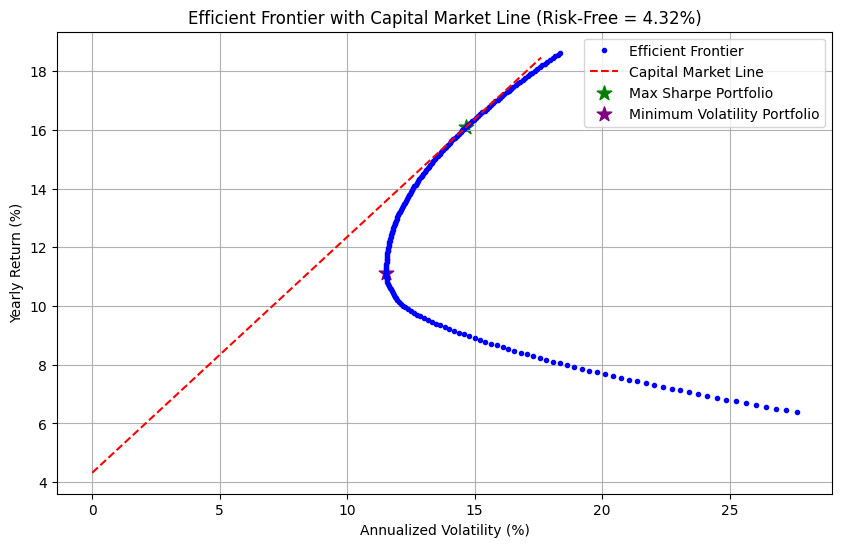

                   Ticker     16.109724     11.123921
0                     VGT  6.236530e+01  4.720935e-17
1                     XLF  6.462364e-19  4.710211e-18
2                     XLY -2.465820e-20  3.187445e-17
3                     XLV  2.457291e+01  2.963248e+01
4                     VOX  3.023370e-19  5.997947e+00
5                     XLI  3.864594e-19  8.647983e-18
6                     XLP  3.204838e-19  4.294047e+01
7                     XLE  1.002230e-18 -2.964871e-17
8                     VNQ  1.031853e-20 -2.249020e-18
9                     XLB  8.136389e-19 -1.337822e-17
10                    XLU  1.306179e+01  2.142910e+01
11             Volatility  4.234382e+00  3.326624e+00
12  Annualized Volatility  1.466833e+01  1.152376e+01


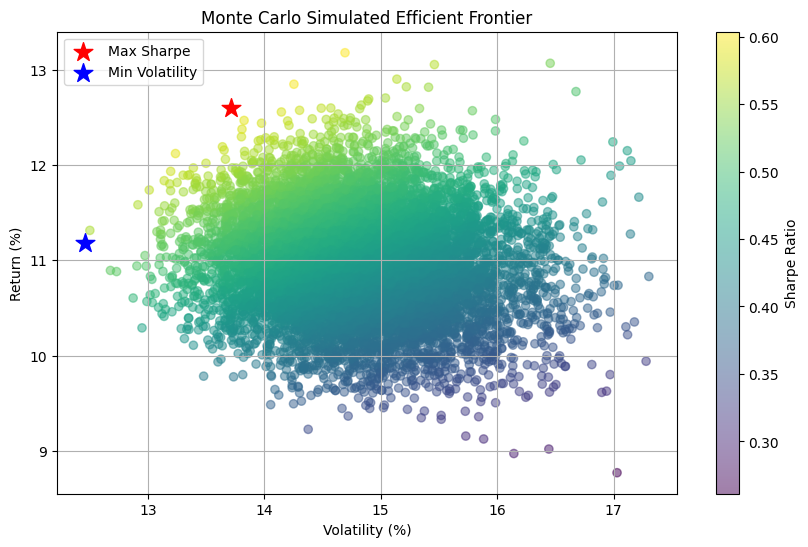

(      Return (%)  Volatility (%)  Sharpe Ratio
0      11.489838       13.369694      0.536275
1      10.779424       15.431422      0.418589
2      11.449236       15.007723      0.475038
3      11.536737       14.911071      0.483985
4      11.612422       15.379551      0.474163
...          ...             ...           ...
9995   11.424350       14.749653      0.481662
9996   10.705634       14.364422      0.444545
9997   10.830673       14.458872      0.450289
9998   10.787732       14.957639      0.432403
9999   10.810320       14.360089      0.451969

[10000 rows x 3 columns], Ticker       VGT       XLF       XLY       XLV       VOX       XLI       XLP  \
0       0.057677  0.012641  0.141783  0.149802  0.050963  0.138999  0.154450   
1       0.100602  0.070072  0.111732  0.101540  0.033169  0.063905  0.036875   
2       0.106088  0.067721  0.109183  0.037297  0.185449  0.166860  0.033291   
3       0.085464  0.110556  0.150364  0.059166  0.163401  0.100568  0.117325   
4       

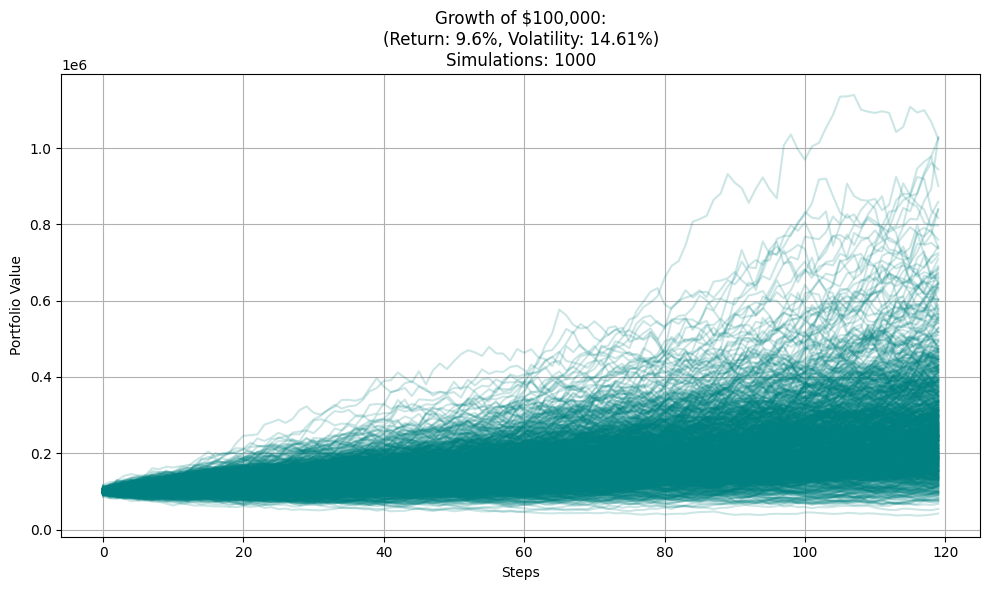

(array([[ 86854.85599033,  90653.17019129,  90213.79818575, ...,
        321235.78019519, 308540.13172392, 338542.33866552],
       [105350.72215149, 103024.27088521,  98564.78281882, ...,
        274819.44063327, 282148.60849739, 273620.54727213],
       [102324.72747234, 100994.18449042,  97796.95954084, ...,
        199621.72835189, 197262.23577099, 199291.79166131],
       ...,
       [ 99335.87972645, 100010.68592658, 105703.28737971, ...,
        455973.80134286, 455990.48617488, 473020.84046621],
       [ 94349.4003359 ,  96010.37247555, 104395.5996078 , ...,
        141865.98620278, 150935.75531331, 156313.55679765],
       [ 97688.89123024,  96639.20558444,  98397.39311428, ...,
        193512.91621507, 207057.55724053, 202100.72080619]],
      shape=(1000, 120)), np.float64(9.601861003659797), np.float64(14.6129319521354))


In [33]:
etf_data = log_returns_dict['ETF, 15 Year Monthly']

# Summary statistics
print(summary_table(etf_data, month))

# Optimal portfolios at selected target returns (must be within the feasible range)
print(multi_optimization(etf_data, month, (0.07, 0.09, 0.11, 0.13, 0.15, 0.17)))

# Efficient frontier with Capital Market Line (risk-free rate = 4.32%)
print(efficient_frontier_cml(etf_data, month, 0.0432))

# Monte Carlo simulated efficient frontier (10,000 random portfolios)
print(monte_carlo_efficient_frontier(etf_data, month, 10000, 0.0432))

# Monte Carlo portfolio growth simulation (1,000 simulations, 10-year horizon, $100,000 initial investment)
print(monte_carlo_portfolio_paths(etf_data, month, 12, 1000, 10, 100000))